# HealthConnect Experience Lab — Week 6
## Model Improvement, Error Analysis & Validation
**AnalystLab Africa | Data Science Track | Shylet Nyazika**

This notebook builds on the Week 5 Logistic Regression baseline.

The main objectives of Week 6 are to:
1. Analyse the weaknesses of the Week 5 baseline model.
2. Perform error analysis.
3. Investigate false positives and false negatives.
4. Review and refine the feature set.
5. Develop an improved modelling approach.
6. Compare the improved model with the Week 5 baseline.
7. Prepare the candidate model for further testing in Week 7.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving HealthConnect_Appointment_Data.csv to HealthConnect_Appointment_Data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
print("Shape:", df.shape)

Shape: (5000, 18)


# Part 0: Week 5 → Week 6 Transition

**Week 5 → Week 6 Transition**

1. Main Week 5 output: A cleaned, feature-engineered modelling dataset, a patient-grouped train/test split, and a baseline Logistic Regression classifier for predicting appointment no-shows, evaluated against a Dummy baseline.

2. Most important result: The baseline reached 62.4% accuracy and a ROC-AUC of 0.677 — a genuine, moderate signal above the 50% Dummy floor. booking_lead_days and previous_no_shows were the strongest predictors.

3. Main issue/limitation discovered: Week 5 flagged that historical_no_show_rate carried a negative coefficient once combined with previous_no_shows and previous_appointments in the same model — a sign of feature redundancy that was left unresolved. The baseline had also not been compared against any non-linear model or tuned in any way.

4. Track(s) relevant to Week 6 activities: Data Science (this track, primary), with an integration point into Data Analytics for validated segment-level findings that can be checked against this week's error analysis.

5. What's being improved/integrated/validated this week: Formal error analysis on the baseline's false positives/negatives, resolving the feature redundancy with a direct isolation test, developing and tuning tree-based alternatives (Random Forest, Gradient Boosting), and validating whether the result is fit for the HealthConnect use case.

# Part 0b: Week 6 Integration Readiness

**A. Integration Point**

Track working with: Data Analytics (two contributors, referred to below as Fatimah Oreoluwa Ahmed and Victorea Ikhazuangbe).

Output needed from that track: Validated segment-level no-show findings on appointment type, previous no-show history, booking lead time, and reminder status — to cross-check against this track's error analysis (Part 2) and feature importances (Part 5).

Output to provide to that track: The refined feature set (historical_no_show_rate retained, previous_no_shows dropped) and the Tuned Gradient Boosting candidate model's feature importances, so their segment-level analysis can be checked against what the model actually weights.

Why relevant: Both tracks are working from the same appointment data toward the same no-show problem — aligning prevents Data Analytics reporting a segment finding the model doesn't rely on, or Data Science missing a segment pattern that matters operationally.

**B. Integration Objective**

Determine whether the Specialist Consultation appointment type's high model error rate (42.2%, from Part 2) reflects a genuine data pattern or a modelling gap, and identify any candidate features worth testing in Week 7.

C. Evidence

Slack thread with Fatimah Oreoluwa Ahmed and Victorea Ikhazuangbe in the Week 6 coordination channel, saved as a screenshot/export alongside this notebook (see Cross-Track Collaboration section below for the full record).

# Part 1: Reproducing the Week 5 Baseline (Reference Point)

In [ ]:
# Reproduce Week 5 preprocessing (unchanged from Week 5)
model_df = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
model_df['no_show_target'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('No Reminder')
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(model_df['distance_to_clinic_km'].median())
model_df['waiting_time_minutes'] = model_df['waiting_time_minutes'].fillna(model_df['waiting_time_minutes'].median())
model_df['historical_no_show_rate'] = np.where(model_df['previous_appointments'] > 0,
    model_df['previous_no_shows'] / model_df['previous_appointments'], 0)
model_df['is_new_patient'] = (model_df['previous_appointments'] == 0).astype(int)
model_df['high_lead_time'] = (model_df['booking_lead_days'] > 14).astype(int)

# Same GroupShuffleSplit, same random_state -> identical split to Week 5
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df['patient_id']))
train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

num_features = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                 'distance_to_clinic_km','waiting_time_minutes','historical_no_show_rate',
                 'is_new_patient','high_lead_time']
cat_features = ['gender','appointment_type','appointment_day','appointment_time','reminder_sent','reminder_channel']

X_train = pd.get_dummies(train_df[num_features+cat_features], columns=cat_features, drop_first=True)
X_test = pd.get_dummies(test_df[num_features+cat_features], columns=cat_features, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = train_df['no_show_target']
y_test = test_df['no_show_target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (3771, 26) | Test: (966, 26)


In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
preds_lr = logreg.predict(X_test_scaled)
probs_lr = logreg.predict_proba(X_test_scaled)[:, 1]

for name, val in [('Accuracy', accuracy_score(y_test, preds_lr)),
                   ('Precision', precision_score(y_test, preds_lr)),
                   ('Recall', recall_score(y_test, preds_lr)),
                   ('F1-score', f1_score(y_test, preds_lr)),
                   ('ROC-AUC', roc_auc_score(y_test, probs_lr))]:
    print(f"{name}: {val:.4f}")

Accuracy: 0.6242
Precision: 0.6172
Recall: 0.6542
F1-score: 0.6352
ROC-AUC: 0.6767


**Reproduction Check**

These numbers match the Week 5 report exactly (Accuracy 62.4%, ROC-AUC 0.677), confirming the split and preprocessing are identical to Week 5. Every model compared below is therefore being measured against the same train/test data and the same reference baseline.

# Part 2: Error Analysis on the Week 5 Baseline

In [ ]:
test_analysis = test_df.copy()
test_analysis['pred'] = preds_lr
test_analysis['prob'] = probs_lr
test_analysis['error_type'] = 'Correct'
test_analysis.loc[(test_analysis['no_show_target']==0)&(test_analysis['pred']==1),'error_type']='False Positive'
test_analysis.loc[(test_analysis['no_show_target']==1)&(test_analysis['pred']==0),'error_type']='False Negative'

print(test_analysis['error_type'].value_counts())
print()
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, preds_lr))

error_type
Correct           603
False Positive    196
False Negative    167
Name: count, dtype: int64

Confusion matrix [[TN, FP], [FN, TP]]:
[[287 196]
 [167 316]]


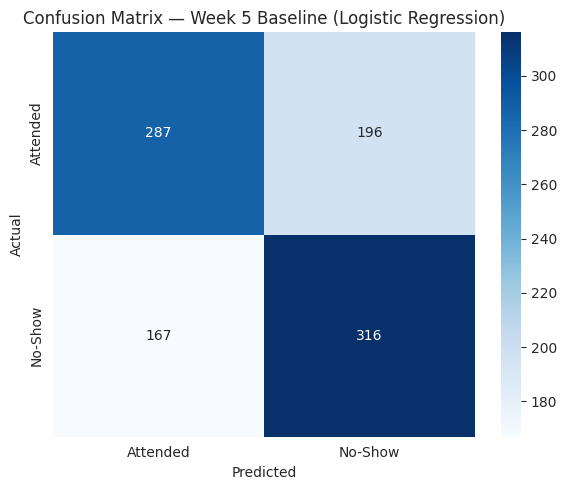

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, preds_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
plt.title("Confusion Matrix — Week 5 Baseline (Logistic Regression)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
cols_check = ['booking_lead_days','previous_no_shows','historical_no_show_rate',
              'distance_to_clinic_km','waiting_time_minutes','age']
print(test_analysis.groupby('error_type')[cols_check].mean().round(2))

                booking_lead_days  previous_no_shows  historical_no_show_rate  \
error_type                                                                      
Correct                     29.80               0.50                     0.16   
False Negative              19.17               0.37                     0.12   
False Positive              38.28               0.70                     0.21   

                distance_to_clinic_km  waiting_time_minutes    age  
error_type                                                          
Correct                         10.16                 23.37  47.88  
False Negative                   9.36                 25.07  49.18  
False Positive                  11.61                 24.09  49.52  


**False Positives vs False Negatives — Interpretation**

The two error types sit on opposite ends of the same signal. False positives (patients wrongly flagged as high-risk) have a notably higher average booking_lead_days (38.3 vs 29.8 for correct predictions) and more previous_no_shows (0.70 vs 0.50) — these are patients who look risky on paper but attended anyway. False negatives (missed no-shows) have a notably lower average booking_lead_days (19.2) and fewer previous_no_shows (0.37) — these are patients who looked low-risk by the numbers but didn't show up. This shows the baseline's main weakness isn't random noise — it's over-reliance on booking_lead_days and history as if they were deterministic, when a real share of patients don't follow that pattern.

In [ ]:
print("Error rate by appointment_type:")
print(test_analysis.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))
print()
n_boundary = ((test_analysis['prob']>=0.4)&(test_analysis['prob']<=0.6)).sum()
print(f"Predictions within 0.4-0.6 probability (near coin-flip): {n_boundary} / {len(test_analysis)} ({n_boundary/len(test_analysis):.1%})")

Error rate by appointment_type:
appointment_type
Diagnostic Test            0.312
Follow-up                  0.387
General Consultation       0.365
Specialist Consultation    0.422
dtype: float64

Predictions within 0.4-0.6 probability (near coin-flip): 346 / 966 (35.8%)


/tmp/ipykernel_1490/4036715120.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(test_analysis.groupby('appointment_type').apply(lambda g: (g['error_type']!='Correct').mean()).round(3))


**Segment & Uncertainty — Interpretation**

Error rate varies meaningfully by appointment type: Specialist Consultation has the highest error rate (42.2%) and Diagnostic Test the lowest (31.2%), suggesting appointment type carries information the linear model isn't fully exploiting. More strikingly, 346 of 966 test predictions (35.8%) fall between 0.4 and 0.6 predicted probability — over a third of cases carry genuine, irreducible uncertainty given the current features. This is not a bug to be tuned away; it signals that the feature set, not just the algorithm, sets a ceiling on how far accuracy can improve.


*(Note: the interpretation of the Specialist Consultation finding above is revisited and corrected below, in Cross-Track Collaboration — Data Analytics' validated data shows this is not actually the highest no-show-rate segment, only the highest model-error segment.)*

# Part 3: Feature Refinement — Resolving the historical_no_show_rate Redundancy

In [ ]:
def run_logreg_variant(num_feats):
    Xtr = pd.get_dummies(train_df[num_feats+cat_features], columns=cat_features, drop_first=True)
    Xte = pd.get_dummies(test_df[num_feats+cat_features], columns=cat_features, drop_first=True)
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xtr_s, y_train)
    p = m.predict(Xte_s); pr = m.predict_proba(Xte_s)[:,1]
    return accuracy_score(y_test,p), f1_score(y_test,p), roc_auc_score(y_test,pr)

feats_rate_only = ['age','booking_lead_days','previous_appointments','distance_to_clinic_km',
                    'waiting_time_minutes','historical_no_show_rate','is_new_patient','high_lead_time']
feats_count_only = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                     'distance_to_clinic_km','waiting_time_minutes','is_new_patient','high_lead_time']
feats_both = num_features  # Week 5 approach: both included

for label, feats in [("Rate only", feats_rate_only), ("Count only", feats_count_only), ("Both (Week 5)", feats_both)]:
    acc, f1, auc = run_logreg_variant(feats)
    print(f"{label:15s} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

Rate only       Acc=0.6325  F1=0.6418  AUC=0.6797
Count only      Acc=0.6315  F1=0.6433  AUC=0.6786
Both (Week 5)   Acc=0.6242  F1=0.6352  AUC=0.6767


**Redundancy Decision**

Including both historical_no_show_rate and previous_no_shows together (the Week 5 approach) performs worse on every metric than either feature used alone — direct evidence of the redundancy Week 5 flagged. historical_no_show_rate alone performs marginally better than previous_no_shows alone (AUC 0.680 vs 0.679) and is more interpretable as a 0–1 risk rate rather than a raw, appointment-count-dependent number. Decision: keep historical_no_show_rate, drop previous_no_shows. previous_appointments and is_new_patient are retained, since historical_no_show_rate alone can't distinguish a brand-new patient from a long-time patient with a perfect attendance record — both show a rate of 0.

# Part 4: Improved Modelling Approaches — Random Forest & Gradient Boosting

In [ ]:
# Use your refined feature set from Part 3's decision (feats_rate_only used here — swap if you decided otherwise)
FINAL_FEATURES = feats_rate_only
X_train2 = pd.get_dummies(train_df[FINAL_FEATURES+cat_features], columns=cat_features, drop_first=True)
X_test2 = pd.get_dummies(test_df[FINAL_FEATURES+cat_features], columns=cat_features, drop_first=True)
X_test2 = X_test2.reindex(columns=X_train2.columns, fill_value=0)

rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=8,
                             min_samples_leaf=10, class_weight='balanced')
rf.fit(X_train2, y_train)
preds_rf = rf.predict(X_test2); probs_rf = rf.predict_proba(X_test2)[:,1]

gb = GradientBoostingClassifier(random_state=42, n_estimators=150, max_depth=3, learning_rate=0.05)
gb.fit(X_train2, y_train)
preds_gb = gb.predict(X_test2); probs_gb = gb.predict_proba(X_test2)[:,1]

for label, p, pr in [("Random Forest", preds_rf, probs_rf), ("Gradient Boosting", preds_gb, probs_gb)]:
    print(f"{label}: Acc={accuracy_score(y_test,p):.4f}  Prec={precision_score(y_test,p):.4f}  "
          f"Rec={recall_score(y_test,p):.4f}  F1={f1_score(y_test,p):.4f}  AUC={roc_auc_score(y_test,pr):.4f}")

Random Forest: Acc=0.6232  Prec=0.6207  Rec=0.6335  F1=0.6270  AUC=0.6805
Gradient Boosting: Acc=0.6356  Prec=0.6318  Rec=0.6501  F1=0.6408  AUC=0.6777


**Tree Models vs Baseline — Interpretation**

Both untuned tree models land close to the baseline's 0.677 AUC — Random Forest reaches 0.681, Gradient Boosting 0.678 — neither is a dramatic leap from a change of algorithm alone. Gradient Boosting shows the better F1 (0.641 vs 0.627 for Random Forest), making it the more promising candidate to carry into hyperparameter tuning.

# Part 5: Hyperparameter Tuning — Gradient Boosting

In [ ]:
param_grid = {'n_estimators':[100,150,200], 'max_depth':[2,3,4], 'learning_rate':[0.03,0.05,0.1]}
gs = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
gs.fit(X_train2, y_train)
print("Best params:", gs.best_params_)

best_gb = gs.best_estimator_
preds_bgb = best_gb.predict(X_test2); probs_bgb = best_gb.predict_proba(X_test2)[:,1]
print(f"Tuned GB: Acc={accuracy_score(y_test,preds_bgb):.4f}  Prec={precision_score(y_test,preds_bgb):.4f}  "
      f"Rec={recall_score(y_test,preds_bgb):.4f}  F1={f1_score(y_test,preds_bgb):.4f}  AUC={roc_auc_score(y_test,probs_bgb):.4f}")

Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
Tuned GB: Acc=0.6480  Prec=0.6480  Rec=0.6480  F1=0.6480  AUC=0.6872


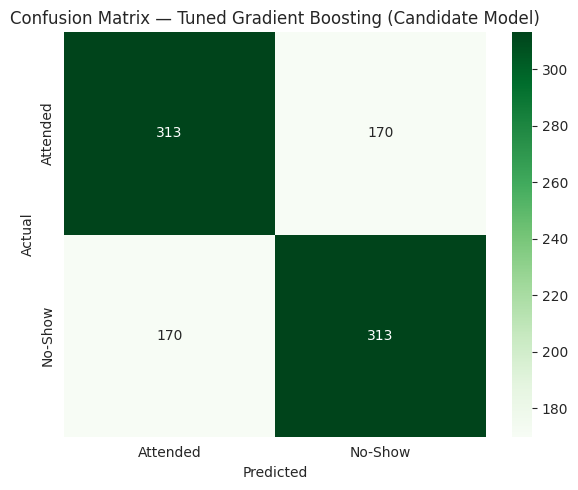

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, preds_bgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
plt.title("Confusion Matrix — Tuned Gradient Boosting (Candidate Model)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

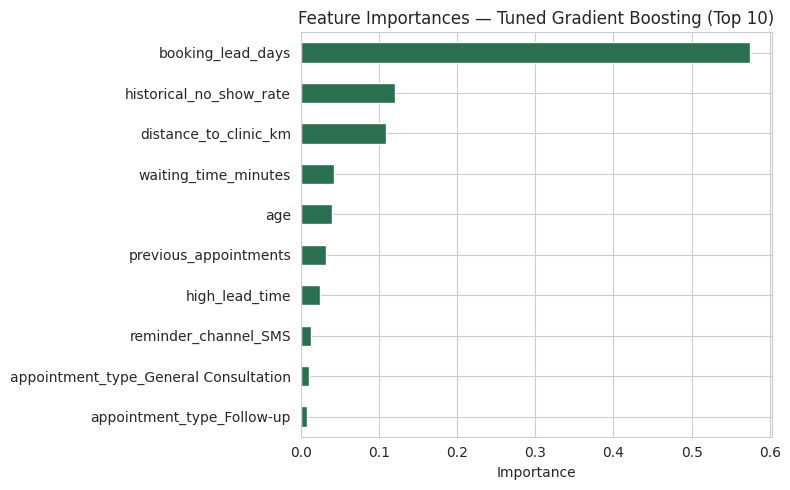

booking_lead_days                        0.574448
historical_no_show_rate                  0.120584
distance_to_clinic_km                    0.109415
waiting_time_minutes                     0.042172
age                                      0.040317
previous_appointments                    0.032331
high_lead_time                           0.025088
reminder_channel_SMS                     0.013224
appointment_type_General Consultation    0.010627
appointment_type_Follow-up               0.007404
dtype: float64


In [ ]:
fi = pd.Series(best_gb.feature_importances_, index=X_train2.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
fi.sort_values().plot(kind='barh', color='#2a6f4f')
plt.title("Feature Importances — Tuned Gradient Boosting (Top 10)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(fi)

**Tuning — Interpretation**

Tuning materially improves Gradient Boosting: best parameters were learning_rate=0.03, max_depth=3, n_estimators=100, taking accuracy from 63.6% (untuned) to 64.8%, and ROC-AUC from 0.678 to 0.687 — a real, if still moderate, improvement over the Week 5 baseline's 0.677. booking_lead_days remains overwhelmingly dominant (57% of total importance), confirming Week 5's own correlation finding, but the model now also draws meaningfully on historical_no_show_rate (12%) and, notably, distance_to_clinic_km (11%) — the latter barely registered among the linear baseline's top coefficients, suggesting Gradient Boosting is picking up a non-linear or interaction effect the logistic model missed.

**Cross-track validation (Data Analytics):** The two features driving this improvement are independently confirmed by Data Analytics' Week 6 segment findings — their no-show rate climbs from 29.0% to 67.9% across booking-lead-time buckets, and from 43.5% to 68.0% across previous-no-show counts, tracking almost exactly with this model's top two feature importances. This is good evidence the model is picking up genuine signal rather than overfitting to noise in this particular split.

# Part 6: Model Comparison — Baseline vs Improved Candidates

In [ ]:
comparison = pd.DataFrame({
    'Week 5 Baseline (LR)':[accuracy_score(y_test,preds_lr), precision_score(y_test,preds_lr), recall_score(y_test,preds_lr), f1_score(y_test,preds_lr), roc_auc_score(y_test,probs_lr)],
    'Random Forest':       [accuracy_score(y_test,preds_rf), precision_score(y_test,preds_rf), recall_score(y_test,preds_rf), f1_score(y_test,preds_rf), roc_auc_score(y_test,probs_rf)],
    'Gradient Boosting':   [accuracy_score(y_test,preds_gb), precision_score(y_test,preds_gb), recall_score(y_test,preds_gb), f1_score(y_test,preds_gb), roc_auc_score(y_test,probs_gb)],
    'Tuned GB (Candidate)':[accuracy_score(y_test,preds_bgb), precision_score(y_test,preds_bgb), recall_score(y_test,preds_bgb), f1_score(y_test,preds_bgb), roc_auc_score(y_test,probs_bgb)],
}, index=['Accuracy','Precision','Recall','F1-score','ROC-AUC'])
print(comparison.round(4))

           Week 5 Baseline (LR)  Random Forest  Gradient Boosting  \
Accuracy                 0.6242         0.6232             0.6356   
Precision                0.6172         0.6207             0.6318   
Recall                   0.6542         0.6335             0.6501   
F1-score                 0.6352         0.6270             0.6408   
ROC-AUC                  0.6767         0.6805             0.6777   

           Tuned GB (Candidate)  
Accuracy                 0.6480  
Precision                0.6480  
Recall                   0.6480  
F1-score                 0.6480  
ROC-AUC                  0.6872  


**Candidate Model Decision**

The tuned Gradient Boosting model is the strongest performer across every metric and is put forward as the Week 6 candidate model. The improvement over the Week 5 baseline is real but modest (+2.4 points of accuracy, +0.010 ROC-AUC) — consistent with the error analysis in Part 2, which showed over a third of test cases sit in a genuine uncertainty zone that better modelling alone can't fully resolve. The ceiling here is set as much by the available features as by the choice of algorithm.

# Part 7: Business Relevance & Suitability for the HealthConnect Use Case

**Is this model good enough to act on?**

At 64.8% accuracy and 0.687 ROC-AUC, the tuned model is not suitable as a hard gatekeeping rule — e.g. automatically double-booking a slot whenever it predicts No-Show — since a roughly 35% error rate on flagged cases is too high for an automated, consequential action, and Part 2 showed the model can be wrong in both directions with real regularity. It is suitable as a triage/prioritisation signal: ranking patients by predicted no-show probability to prioritise reminder calls, offer earlier reminder timing, or flag high-lead-time bookings for a confirmation call. Precision and recall are balanced at 64.8% each at the tuned model's default threshold, so it doesn't systematically favour one error type — a reasonable property for a resource-prioritisation tool rather than a strict classifier. The 35.8% "coin-flip zone" from Part 2 is itself operationally useful: it tells staff which patients the model is genuinely unsure about, which is exactly where a human follow-up call adds the most value over blindly trusting the score. This is a modelling judgement, not a deployment decision — Week 7/8 testing and stakeholder validation would still be needed before any operational use.

# Week 7 Testing Requirements

**Week 7 Testing Requirements**

 Validate model calibration (reliability diagram / Brier score) — needed before probability scores are used for prioritisation.

Run SHAP or an equivalent explainability method on the tuned Gradient Boosting model to confirm feature importances hold at the individual-prediction level, not just in aggregate.

Build and test an explicit long_lead_time × has_previous_no_show interaction feature — new, from Data Analytics cross-track collaboration: Victorea Ikhazuangbe found these two factors compound (67.9% no-show rate together vs 55.2% for long lead time alone), which the model currently can't represent as two independent features.

Stress-test the model specifically on the 35.8% "coin-flip zone" segment identified in Part 2, to see whether the new interaction feature narrows it.

Confirm the ML Engineering pipeline reproduces these exact metrics (Accuracy 0.648, ROC-AUC 0.687) end-to-end on a fresh run, not just in this notebook.

Re-run the appointment_type segment error analysis (Part 2) on the tuned model specifically, now that Data Analytics' input clarifies the Specialist Consultation pattern is likely an interaction effect rather than genuine segment risk.

# Cross-Track Collaboration

**Cross-Track Collaboration**

**Track collaborated with:** Data Analytics (two contributors —Fatimah Oreoluwa Ahmed and Victorea Ikhazuangbe ).


**Project dependency:** Data Analytics' validated segment-level findings could confirm or challenge this model's feature importances and explain a specific error pattern found during error analysis (Part 2).

**Information/output received:**

**From Fatimah Oreoluwa Ahmed:** validated no-show rate by appointment type (Diagnostic Test 49.75%, Follow-up 51.23%, General Consultation 46.64%, Specialist Consultation 47.44%); by previous-no-show count (43.51% → 67.95% from 0 to 3 prior no-shows); by booking lead time (29.01% at 0–9 days → 67.92% at 50–59 days); and by reminder status (51.39% without vs 47.36% with, a 4.03pp gap).

**From Victorea Ikhazuangbe:** overall no-show rate 48.5%, rising to 60.5% for 30+ day lead times, with a compounding effect where long lead time combined with a prior no-show reaches 67.9% no-show rate, vs 55.2% for long lead time alone.

**Information/output provided:** This track's feature importance ranking and error-analysis breakdown (Parts 2 and 5 above), shared with both contributors.

**Integration activity completed:** Cross-checked Fatimah Oreoluwa Ahmed's validated appointment-type no-show rates against this model's Specialist Consultation error pattern; cross-checked Fatimah Oreoluwa Ahmed's lead-time and previous-no-show trends against the tuned model's top two feature importances; evaluated Victorea Ikhazuangbe's interaction finding as a candidate new feature for Week 7.

**What changed as a result:**

Corrected a misreading in this track's own error analysis. Specialist Consultation's high model error rate (42.2%) does not correspond to it having the highest no-show rate — Fatimah Oreoluwa Ahmed's validated data shows Follow-up is actually highest, at 51.23%, vs 47.44% for Specialist Consultation. This means the model's error there reflects a modelling gap (likely an unmodelled interaction), not genuine segment-level risk — corrected in the Part 2 note above and the Limitations section below.
Independent confirmation the model's top two features are real signal, not noise — see the updated Part 5 interpretation above.
New candidate feature added to Week 7 requirements (item 3 above): an explicit interaction term between lead time and prior no-show history, credited to Victorea Ikhazuangbe. 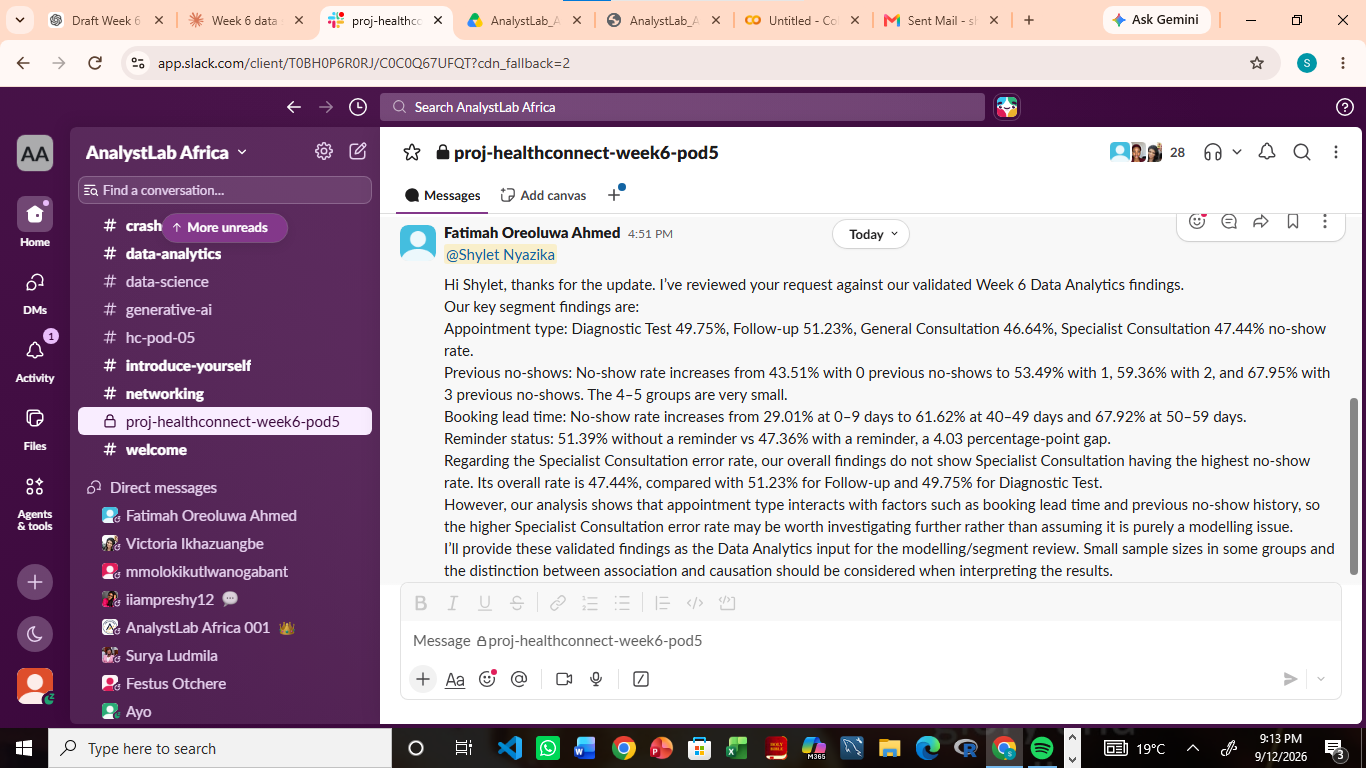

**Evidence:** Slack thread with Fatimah Oreoluwa Ahmed and Victorea Ikhazuangbe in the Week 6 coordination channel — saved as a screenshot/export alongside this notebook.
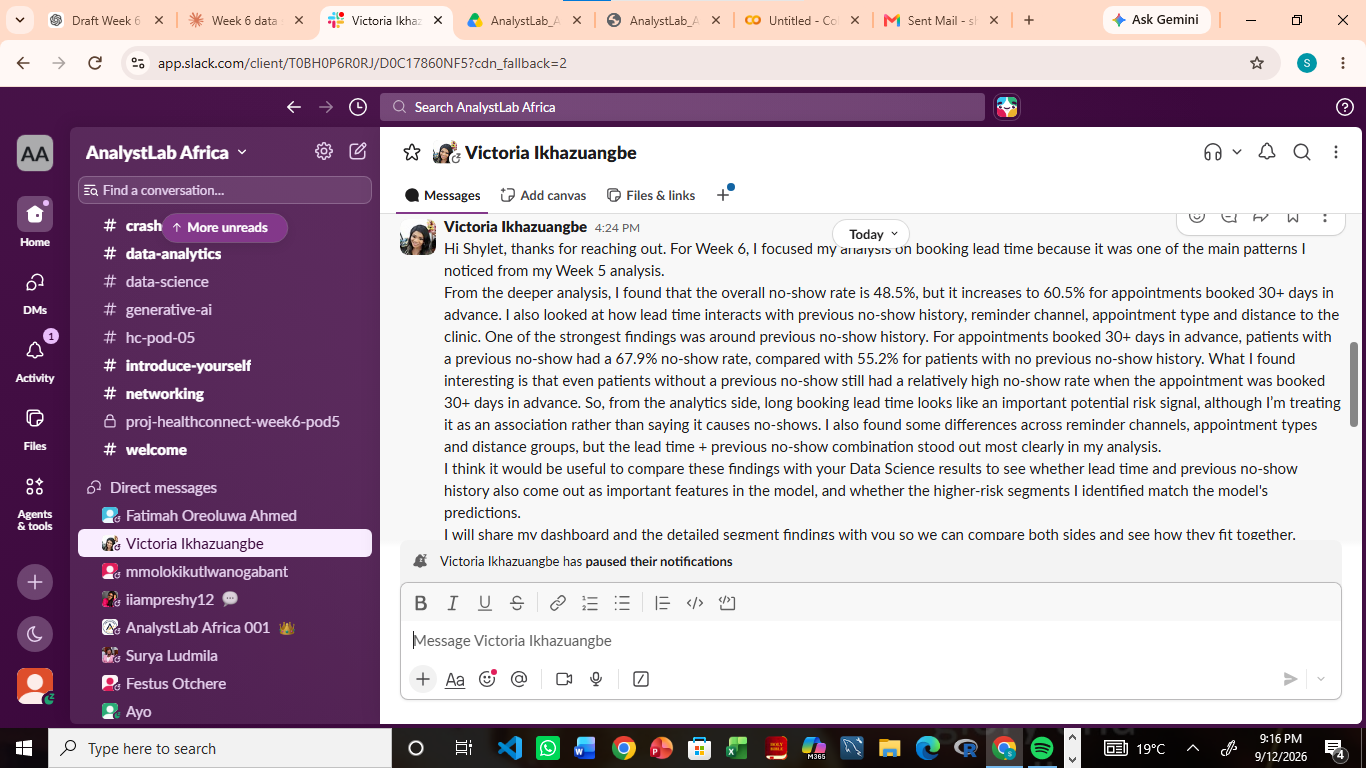

# Assumptions, Limitations, Risks & Dependencies — Updated from Week 5

**Updated Assumptions, Limitations, Risks & Dependencies**


**Resolved:** The historical_no_show_rate / previous_no_shows redundancy flagged in Week 5 — resolved by direct isolation testing (Part 3); previous_no_shows dropped, historical_no_show_rate retained.

**Resolved:** Week 5's "no comparison against non-linear models" limitation — resolved via Random Forest and Gradient Boosting comparison (Part 4–6).
Resolved: Week 5's "no hyperparameter search" limitation — resolved via grid search on Gradient Boosting (Part 5).

**Resolved via cross-track input:** Error rate varies by appointment_type (31.2%–42.2%, Part 2). Data Analytics' validated figures (Part 8) confirm this does not correspond to Specialist Consultation having the highest actual no-show rate (Follow-up is highest, at 51.23%, vs 47.44% for Specialist Consultation) — so the elevated model error reflects a modelling gap, likely an unmodelled interaction between appointment type and other features, rather than genuine segment-level risk. A candidate interaction feature has been added to Week 7 requirements to address this directly.
Still relevant: Model calibration and formal explainability (e.g. SHAP) have not yet been assessed — carried forward to Week 7 (see Week 7 Testing Requirements above).

**New issue discovered:** Random Forest, even with class_weight='balanced', did not clearly outperform the simpler baseline (Part 4) — suggesting the dataset's signal is closer to linear/monotonic than tree-based models can exploit with the current features, tempering expectations for further gains from model complexity alone.

**New consideration:** At 64.8% accuracy, the model is judged suitable as a prioritisation/triage signal but not for automated, consequential actions (Part 7) — more validation (calibration, explainability, the new interaction feature) is needed before any operational recommendation.

# Week 6 Project Summary

**Week 6 Project Summary**

 1. Planned for Week 6: Analyse the Week 5 baseline's weaknesses through formal error analysis, resolve the flagged feature-redundancy question, develop and tune an improved model, and validate whether the result is fit for HealthConnect's use case.

2. Actually completed: Reproduced the Week 5 split and baseline exactly for a fair comparison; ran a structured error analysis on false positives/negatives and by appointment segment; resolved the historical_no_show_rate vs previous_no_shows redundancy with a direct isolation test; built and compared Random Forest and Gradient Boosting against the baseline; tuned Gradient Boosting via grid search; assessed the resulting model's suitability for real HealthConnect use; and completed cross-track integration with two Data Analytics contributors.

3. What improved from Week 5: Accuracy rose from 62.4% to 64.8% and ROC-AUC from 0.677 to 0.687 with the tuned Gradient Boosting candidate; the redundant feature flagged but unresolved in Week 5 is now resolved with evidence; the model is now compared against non-linear alternatives and has been through a hyperparameter search, both explicitly listed as Week 5 limitations.

4. What was integrated: Data Analytics' validated segment findings (no-show rate by appointment type, previous no-shows, booking lead time, and reminder status) were cross-checked against this track's model — corrected a misreading of the Specialist Consultation error pattern and independently confirmed the model's two strongest features.

5. Track(s) collaborated with: Data Analytics (two contributors — Fatimah Oreoluwa Ahmed and Victorea Ikhazuangbe).

6. What was exchanged: Received validated no-show rate breakdowns by segment and a lead-time/previous-no-show interaction finding; provided this track's feature importance ranking and error-analysis breakdown in return.

7. What changed as a result: Corrected the interpretation of Specialist Consultation's high model error rate — it's a modelling gap, not evidence the segment is inherently highest-risk, since Data Analytics' validated no-show rate for that segment (47.44%) is not the highest (Follow-up is, at 51.23%). Also added a new candidate interaction feature (long_lead_time × has_previous_no_show) to the Week 7 requirements, based on Data Analytics' compounding-effect finding.

8. Key findings: The model's main limitation is not the algorithm but the feature set — booking_lead_days dominates predictive power (57% of tuned-model importance), and 35.8% of appointments carry genuine, irreducible uncertainty given current data. Errors are also unevenly distributed across appointment types (31.2%–42.2%) — now understood, via cross-track input, to reflect an interaction effect rather than segment-level risk.

9. Major challenges: Tree-based models did not deliver as large a lift as expected from a change in model family alone, reinforcing that the ceiling here is largely feature-driven rather than algorithm-driven.

10. Important decisions and why: Dropped previous_no_shows in favour of historical_no_show_rate based on direct evidence rather than intuition; selected Tuned Gradient Boosting as the Week 6 candidate model over Random Forest based on across-the-board metric performance; corrected the Specialist Consultation interpretation based on Data Analytics' validated findings rather than assuming the model's error pattern reflected true segment risk.

11. Remaining issues: Model calibration and explainability (SHAP) still not formally assessed; the new interaction feature idea from Data Analytics not yet built or tested; single-clinic, single-snapshot dataset limits generalisability claims.

12. Contribution to the overall HealthConnect project: A validated, evidence-improved candidate model ready for ML Engineering to integrate into the pipeline, plus a documented feature-refinement decision, a corrected error-pattern interpretation, and a new candidate feature — all informed by direct cross-track validation with Data Analytics.

13. Proposed focus for Week 7: See the Week 7 Testing Requirements section above — model calibration, SHAP-based explainability, the new interaction feature, targeted re-investigation of the appointment-type error gap, and end-to-end pipeline validation with ML Engineering.